In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("superstore_sales.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
print("Customer retention dataset check")
print("--------------------------------")

print("Unique customers:", df["Customer ID"].nunique())
print("Total orders:", df["Order ID"].nunique())
print("Total sales:", round(df["Sales"].sum(), 2))

print("\nDate range:")
print(df["Order Date"].min(), "to", df["Order Date"].max())

print("\nMissing values:")
print(df[["Customer ID", "Order Date", "Sales"]].isnull().sum())

Customer retention dataset check
--------------------------------
Unique customers: 793
Total orders: 4922
Total sales: 2261536.78

Date range:
01/01/2018 to 31/12/2017

Missing values:
Customer ID    0
Order Date     0
Sales          0
dtype: int64


In [4]:
# Convert Order Date from text to datetime

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=True
)

print("Order Date data type:", df["Order Date"].dtype)

print("\nCorrect date range:")
print(df["Order Date"].min(), "to", df["Order Date"].max())

Order Date data type: datetime64[ns]

Correct date range:
2015-01-03 00:00:00 to 2018-12-30 00:00:00


In [5]:
customer_metrics = df.groupby("Customer ID").agg(
    First_Purchase=("Order Date", "min"),
    Last_Purchase=("Order Date", "max"),
    Total_Orders=("Order ID", "nunique"),
    Total_Sales=("Sales", "sum")
)

customer_metrics.head()

,First_Purchase,Last_Purchase,Total_Orders,Total_Sales
Customer ID,,,,
AA-10315,2015-03-31,2018-06-29,5,5563.560
AA-10375,2015-04-21,2018-12-11,9,1056.390
AA-10480,2015-05-04,2018-04-15,4,1790.512
AA-10645,2015-06-22,2018-11-05,6,5086.935
AB-10015,2015-02-18,2017-11-10,3,886.156


In [6]:
# Reference date = last date in the dataset
reference_date = df["Order Date"].max()

# Calculate how many days since each customer's last purchase
customer_metrics["Recency_Days"] = (
    reference_date - customer_metrics["Last_Purchase"]
).dt.days

display(customer_metrics.head())

,First_Purchase,Last_Purchase,Total_Orders,Total_Sales,Recency_Days
Customer ID,,,,,
AA-10315,2015-03-31,2018-06-29,5,5563.560,184
AA-10375,2015-04-21,2018-12-11,9,1056.390,19
AA-10480,2015-05-04,2018-04-15,4,1790.512,259
AA-10645,2015-06-22,2018-11-05,6,5086.935,55
AB-10015,2015-02-18,2017-11-10,3,886.156,415


In [7]:
# Calculate customer lifetime in days
customer_metrics["Customer_Lifetime_Days"] = (
    customer_metrics["Last_Purchase"]
    - customer_metrics["First_Purchase"]
).dt.days

# Avoid division by zero for customers with only one purchase
customer_metrics["Purchase_Frequency"] = (
    customer_metrics["Total_Orders"]
    / customer_metrics["Customer_Lifetime_Days"].replace(0, 1)
) * 365

# Average Order Value
customer_metrics["Average_Order_Value"] = (
    customer_metrics["Total_Sales"]
    / customer_metrics["Total_Orders"]
)

display(customer_metrics.head())

,First_Purchase,Last_Purchase,Total_Orders,Total_Sales,Recency_Days,Customer_Lifetime_Days,Purchase_Frequency,Average_Order_Value
Customer ID,,,,,,,,
AA-10315,2015-03-31,2018-06-29,5,5563.560,184,1186,1.538786,1112.712000
AA-10375,2015-04-21,2018-12-11,9,1056.390,19,1330,2.469925,117.376667
AA-10480,2015-05-04,2018-04-15,4,1790.512,259,1077,1.355617,447.628000
AA-10645,2015-06-22,2018-11-05,6,5086.935,55,1232,1.777597,847.822500
AB-10015,2015-02-18,2017-11-10,3,886.156,415,996,1.099398,295.385333


In [8]:
# Assumed planning lifetime
expected_lifetime_years = 3

# Estimate Customer Lifetime Value
customer_metrics["Estimated_CLV"] = (
    customer_metrics["Average_Order_Value"]
    * customer_metrics["Purchase_Frequency"]
    * expected_lifetime_years
)

display(
    customer_metrics[
        [
            "Total_Orders",
            "Total_Sales",
            "Purchase_Frequency",
            "Average_Order_Value",
            "Estimated_CLV"
        ]
    ].head()
)

,Total_Orders,Total_Sales,Purchase_Frequency,Average_Order_Value,Estimated_CLV
Customer ID,,,,,
AA-10315,5,5563.560,1.538786,1112.712000,5136.676391
AA-10375,9,1056.390,2.469925,117.376667,869.734624
AA-10480,4,1790.512,1.355617,447.628000,1820.436992
AA-10645,6,5086.935,1.777597,847.822500,4521.261222
AB-10015,3,886.156,1.099398,295.385333,974.237771


In [9]:
top_clv_customers = customer_metrics.sort_values(
    "Estimated_CLV",
    ascending=False
).head(10)

print("Top 10 Customers by Estimated CLV")
print("----------------------------------")

display(
    top_clv_customers[
        [
            "Total_Orders",
            "Total_Sales",
            "Purchase_Frequency",
            "Average_Order_Value",
            "Estimated_CLV"
        ]
    ]
)

Top 10 Customers by Estimated CLV
----------------------------------


,Total_Orders,Total_Sales,Purchase_Frequency,Average_Order_Value,Estimated_CLV
Customer ID,,,,,
JC-15385,1,1058.108,365.000000,1058.108,1.158628e+06
SM-20905,1,1043.041,365.000000,1043.041,1.142130e+06
TC-21145,1,1038.260,365.000000,1038.260,1.136895e+06
JR-15700,1,863.880,365.000000,863.880,9.459486e+05
PH-18790,1,729.648,365.000000,729.648,7.989646e+05
GR-14560,2,1284.380,365.000000,642.190,7.031981e+05
AO-10810,1,161.280,365.000000,161.280,1.766016e+05
RM-19750,1,98.350,365.000000,98.350,1.076932e+05
CD-12280,2,1205.584,56.153846,602.792,1.015473e+05


In [10]:
# Fix purchase frequency for customers with only one purchase

customer_metrics["Purchase_Frequency"] = np.where(
    customer_metrics["Customer_Lifetime_Days"] <= 0,
    1,
    (
        customer_metrics["Total_Orders"]
        / (customer_metrics["Customer_Lifetime_Days"] / 365)
    )
)

# Recalculate CLV
customer_metrics["Estimated_CLV"] = (
    customer_metrics["Average_Order_Value"]
    * customer_metrics["Purchase_Frequency"]
    * expected_lifetime_years
)

print("Corrected CLV calculation")
print("--------------------------")

display(
    customer_metrics[
        [
            "Total_Orders",
            "Total_Sales",
            "Purchase_Frequency",
            "Average_Order_Value",
            "Estimated_CLV"
        ]
    ].head()
)

Corrected CLV calculation
--------------------------


,Total_Orders,Total_Sales,Purchase_Frequency,Average_Order_Value,Estimated_CLV
Customer ID,,,,,
AA-10315,5,5563.560,1.538786,1112.712000,5136.676391
AA-10375,9,1056.390,2.469925,117.376667,869.734624
AA-10480,4,1790.512,1.355617,447.628000,1820.436992
AA-10645,6,5086.935,1.777597,847.822500,4521.261222
AB-10015,3,886.156,1.099398,295.385333,974.237771


In [11]:
top_clv_customers = customer_metrics.sort_values(
    "Estimated_CLV",
    ascending=False
).head(10)

print("Top 10 Customers by Estimated CLV")
print("----------------------------------")

display(
    top_clv_customers[
        [
            "Total_Orders",
            "Total_Sales",
            "Purchase_Frequency",
            "Average_Order_Value",
            "Estimated_CLV"
        ]
    ]
)

Top 10 Customers by Estimated CLV
----------------------------------


,Total_Orders,Total_Sales,Purchase_Frequency,Average_Order_Value,Estimated_CLV
Customer ID,,,,,
GR-14560,2,1284.380,365.000000,642.19000,703198.050000
CD-12280,2,1205.584,56.153846,602.79200,101547.267692
RB-19360,6,15117.339,4.040590,2519.55650,30541.487463
TC-20980,5,19052.218,2.433333,3810.44360,27816.238280
CJ-12010,8,11164.974,6.199575,1395.62175,25956.786688
CC-12370,5,12129.072,3.360958,2425.81440,24459.178343
SM-20320,5,25043.050,1.399540,5008.61000,21029.248275
PF-19120,4,9062.864,2.914172,2265.71600,19808.056048
AB-10105,10,14473.571,3.427230,1447.35710,14881.277225


In [12]:
# Calculate a stable annual purchase frequency

customer_metrics["Purchase_Frequency"] = (
    customer_metrics["Total_Orders"]
    / np.maximum(
        customer_metrics["Customer_Lifetime_Days"] / 365,
        1
    )
)

# Recalculate estimated CLV
customer_metrics["Estimated_CLV"] = (
    customer_metrics["Average_Order_Value"]
    * customer_metrics["Purchase_Frequency"]
    * expected_lifetime_years
)

print("Corrected CLV calculation")
print("--------------------------")

display(
    customer_metrics[
        [
            "Total_Orders",
            "Total_Sales",
            "Customer_Lifetime_Days",
            "Purchase_Frequency",
            "Average_Order_Value",
            "Estimated_CLV"
        ]
    ].head()
)

Corrected CLV calculation
--------------------------


,Total_Orders,Total_Sales,Customer_Lifetime_Days,Purchase_Frequency,Average_Order_Value,Estimated_CLV
Customer ID,,,,,,
AA-10315,5,5563.560,1186,1.538786,1112.712000,5136.676391
AA-10375,9,1056.390,1330,2.469925,117.376667,869.734624
AA-10480,4,1790.512,1077,1.355617,447.628000,1820.436992
AA-10645,6,5086.935,1232,1.777597,847.822500,4521.261222
AB-10015,3,886.156,996,1.099398,295.385333,974.237771


In [13]:
top_clv_customers = customer_metrics.sort_values(
    "Estimated_CLV",
    ascending=False
).head(10)

display(
    top_clv_customers[
        [
            "Total_Orders",
            "Total_Sales",
            "Customer_Lifetime_Days",
            "Purchase_Frequency",
            "Average_Order_Value",
            "Estimated_CLV"
        ]
    ]
)

,Total_Orders,Total_Sales,Customer_Lifetime_Days,Purchase_Frequency,Average_Order_Value,Estimated_CLV
Customer ID,,,,,,
RB-19360,6,15117.339,542,4.040590,2519.556500,30541.487463
TC-20980,5,19052.218,750,2.433333,3810.443600,27816.238280
CJ-12010,8,11164.974,471,6.199575,1395.621750,25956.786688
CC-12370,5,12129.072,543,3.360958,2425.814400,24459.178343
SM-20320,5,25043.050,1304,1.399540,5008.610000,21029.248275
PF-19120,4,9062.864,501,2.914172,2265.716000,19808.056048
AB-10105,10,14473.571,1065,3.427230,1447.357100,14881.277225
BS-11365,5,10501.653,778,2.345758,2100.330600,14780.604158
SC-20095,9,14142.334,1068,3.075843,1571.370444,14499.864916


In [14]:
top_clv_customers = customer_metrics.sort_values(
    "Estimated_CLV",
    ascending=False
).head(10)

print("Top 10 Customers by Estimated CLV")
print("----------------------------------")

display(
    top_clv_customers[
        [
            "Total_Sales",
            "Total_Orders",
            "Purchase_Frequency",
            "Average_Order_Value",
            "Estimated_CLV"
        ]
    ]
)

Top 10 Customers by Estimated CLV
----------------------------------


,Total_Sales,Total_Orders,Purchase_Frequency,Average_Order_Value,Estimated_CLV
Customer ID,,,,,
RB-19360,15117.339,6,4.040590,2519.556500,30541.487463
TC-20980,19052.218,5,2.433333,3810.443600,27816.238280
CJ-12010,11164.974,8,6.199575,1395.621750,25956.786688
CC-12370,12129.072,5,3.360958,2425.814400,24459.178343
SM-20320,25043.050,5,1.399540,5008.610000,21029.248275
PF-19120,9062.864,4,2.914172,2265.716000,19808.056048
AB-10105,14473.571,10,3.427230,1447.357100,14881.277225
BS-11365,10501.653,5,2.345758,2100.330600,14780.604158
SC-20095,14142.334,9,3.075843,1571.370444,14499.864916


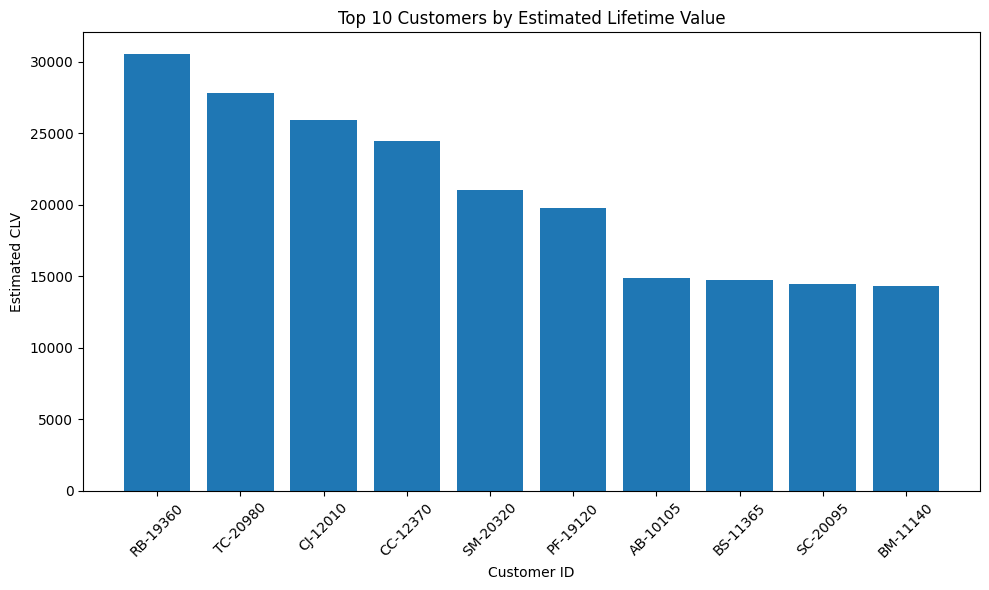

In [15]:
plt.figure(figsize=(10, 6))

plt.bar(
    top_clv_customers.index,
    top_clv_customers["Estimated_CLV"]
)

plt.title("Top 10 Customers by Estimated Lifetime Value")
plt.xlabel("Customer ID")
plt.ylabel("Estimated CLV")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [16]:
# Define retention status based on recency

customer_metrics["Retention_Status"] = pd.cut(
    customer_metrics["Recency_Days"],
    bins=[-1, 90, 180, float("inf")],
    labels=["Active", "At Risk", "Inactive"]
)

print("Customer Retention Status")
print("-------------------------")

display(
    customer_metrics["Retention_Status"]
    .value_counts()
)

Customer Retention Status
-------------------------


Retention_Status
Active      434
Inactive    202
At Risk     157
Name: count, dtype: int64

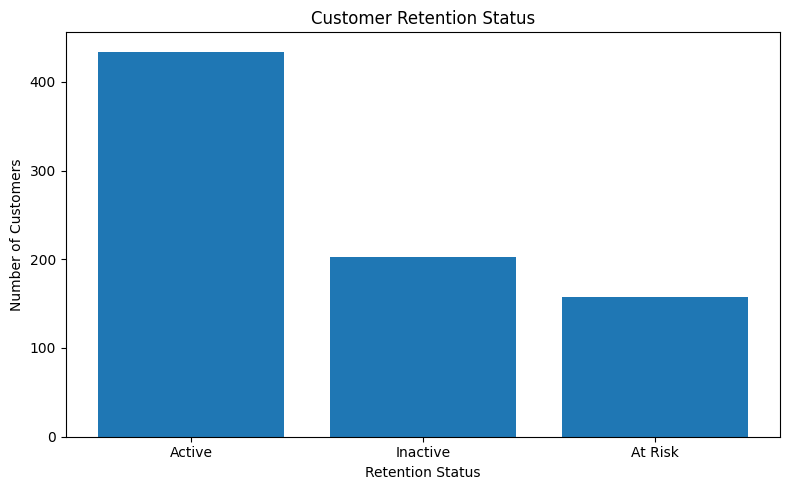

In [17]:
retention_counts = customer_metrics["Retention_Status"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    retention_counts.index,
    retention_counts.values
)

plt.title("Customer Retention Status")
plt.xlabel("Retention Status")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [18]:
clv_by_retention = customer_metrics.groupby(
    "Retention_Status",
    observed=True
)["Estimated_CLV"].mean()

print("Average Estimated CLV by Retention Status")
print("------------------------------------------")

display(clv_by_retention)

Average Estimated CLV by Retention Status
------------------------------------------


Retention_Status
Active      3187.554609
At Risk     3226.212492
Inactive    3298.974771
Name: Estimated_CLV, dtype: float64

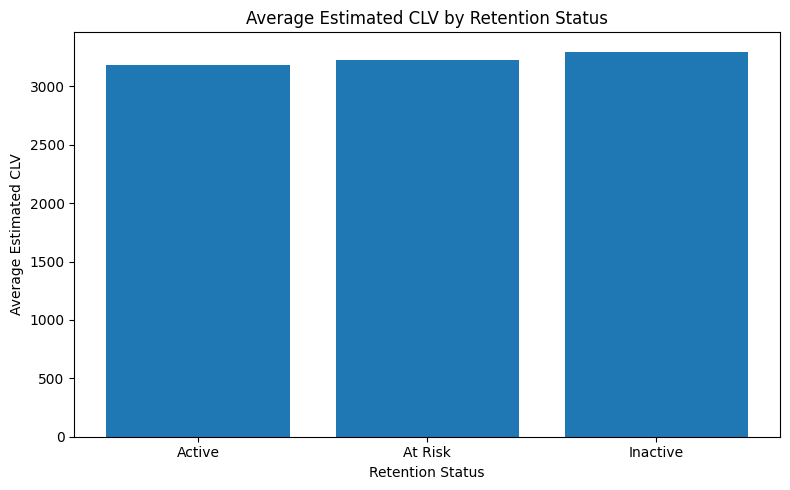

In [19]:
plt.figure(figsize=(8, 5))

plt.bar(
    clv_by_retention.index,
    clv_by_retention.values
)

plt.title("Average Estimated CLV by Retention Status")
plt.xlabel("Retention Status")
plt.ylabel("Average Estimated CLV")

plt.tight_layout()
plt.show()

In [20]:
# Find high-value customers who are not currently active

high_value_at_risk = customer_metrics[
    customer_metrics["Retention_Status"].isin(["At Risk", "Inactive"])
].sort_values(
    "Estimated_CLV",
    ascending=False
).head(10)

print("High-Value At-Risk / Inactive Customers")
print("-----------------------------------------")

display(
    high_value_at_risk[
        [
            "Total_Sales",
            "Total_Orders",
            "Recency_Days",
            "Purchase_Frequency",
            "Average_Order_Value",
            "Estimated_CLV",
            "Retention_Status"
        ]
    ]
)

High-Value At-Risk / Inactive Customers
-----------------------------------------


,Total_Sales,Total_Orders,Recency_Days,Purchase_Frequency,Average_Order_Value,Estimated_CLV,Retention_Status
Customer ID,,,,,,,
RB-19360,15117.3390,6,96,4.040590,2519.556500,30541.487463,At Risk
TC-20980,19052.2180,5,399,2.433333,3810.443600,27816.238280,Inactive
CJ-12010,11164.9740,8,189,6.199575,1395.621750,25956.786688,Inactive
PF-19120,9062.8640,4,834,2.914172,2265.716000,19808.056048,Inactive
BS-11365,10501.6530,5,558,2.345758,2100.330600,14780.604158,Inactive
SC-20095,14142.3340,9,349,3.075843,1571.370444,14499.864916,Inactive
BM-11140,11789.6300,4,307,1.618625,2947.407500,14312.244845,Inactive
KD-16270,8282.3580,5,484,2.760968,1656.471600,13720.396384,Inactive
CM-12715,3984.4524,4,1034,4.000000,996.113100,11953.357200,Inactive


In [21]:
print("Customer Retention Recommendations")
print("----------------------------------")

print("1. Active Customers")
print("   - Reward loyal customers with personalized offers.")
print("   - Encourage repeat purchases through loyalty programs.")

print("\n2. At Risk Customers")
print("   - Send targeted offers and reminders.")
print("   - Prioritize high-CLV customers for retention campaigns.")

print("\n3. Inactive Customers")
print("   - Run re-engagement campaigns.")
print("   - Offer personalized discounts to encourage return purchases.")

print("\n4. High-Value Customers")
print("   - Provide loyalty benefits and personalized recommendations.")
print("   - Focus retention efforts on customers with high Estimated CLV.")

Customer Retention Recommendations
----------------------------------
1. Active Customers
   - Reward loyal customers with personalized offers.
   - Encourage repeat purchases through loyalty programs.

2. At Risk Customers
   - Send targeted offers and reminders.
   - Prioritize high-CLV customers for retention campaigns.

3. Inactive Customers
   - Run re-engagement campaigns.
   - Offer personalized discounts to encourage return purchases.

4. High-Value Customers
   - Provide loyalty benefits and personalized recommendations.
   - Focus retention efforts on customers with high Estimated CLV.
